<a href="https://colab.research.google.com/github/abhi460729/Generative-AI-and-LLM/blob/main/Product_Recommendation_System_using_Word2Vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import random
from tqdm import tqdm
import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Online_Retail.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [3]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
423167,573137,22437,SET OF 9 BLACK SKULL BALLOONS,1,10/27/11 17:15,1.63,NaN,United Kingdom
284400,561870,16048,TEATIME ROUND PENCIL SHARPENER,24,7/31/11 11:45,0.12,14911.0,EIRE
512806,579516,23426,METAL SIGN DROP YOUR PANTS,1,11/29/11 17:52,2.89,17841.0,United Kingdom
451049,575177,23582,VINTAGE DOILY JUMBO BAG RED,4,11/8/11 18:41,4.13,NaN,United Kingdom
202041,554355,22982,PANTRY PASTRY BRUSH,12,5/24/11 9:20,1.25,16992.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
def report(df):
    col = []
    d_type = []
    uniques = []
    n_uniques = []
    missing_values = []
    mean_of_missing = []

    for i in df.columns:
        col.append(i)
        d_type.append(df[i].dtypes)
        uniques.append(df[i].unique()[:5])
        n_uniques.append(df[i].nunique())
        missing_values.append(df[i].isna().sum())
        mean_of_missing.append(df[i].isna().sum()/len(df))

    return pd.DataFrame({'Column': col, 'dtype': d_type, 'unique sample': uniques, 'n uniques': n_uniques, 'num of missing': missing_values, 'mean of missing': mean_of_missing })


report(df)


,Column,dtype,unique sample,n uniques,num of missing,mean of missing
0,InvoiceNo,object,"[536365, 536366, 536367, 536368, 536369]",25900,0,0.000000
1,StockCode,object,"[85123A, 71053, 84406B, 84029G, 84029E]",4070,0,0.000000
2,Description,object,"[WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...",4223,1454,0.002683
3,Quantity,int64,"[6, 8, 2, 32, 3]",722,0,0.000000
4,InvoiceDate,object,"[12/1/10 8:26, 12/1/10 8:28, 12/1/10 8:34, 12/...",23260,0,0.000000
5,UnitPrice,float64,"[2.55, 3.39, 2.75, 7.65, 4.25]",1630,0,0.000000
6,CustomerID,float64,"[17850.0, 13047.0, 12583.0, 13748.0, 15100.0]",4372,135080,0.249267
7,Country,object,"[United Kingdom, France, Australia, Netherland...",38,0,0.000000


In [6]:
df.dropna(inplace=True)


In [7]:
df.describe()


,Quantity,UnitPrice,CustomerID
count,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,15287.690570
std,248.693370,69.315162,1713.600303
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13953.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df = df[df['Quantity'] > 0]


In [9]:
df.shape


(397924, 8)

In [10]:
TopProducts= df.pivot_table(
    index=['StockCode','Description'],
    values='Quantity',
    aggfunc='sum').sort_values(
    by='Quantity', ascending=False)

TopProducts.head(10)

,,Quantity
StockCode,Description,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995
23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
85099B,JUMBO BAG RED RETROSPOT,46181
85123A,WHITE HANGING HEART T-LIGHT HOLDER,36725
84879,ASSORTED COLOUR BIRD ORNAMENT,35362
21212,PACK OF 72 RETROSPOT CAKE CASES,33693
22197,POPCORN HOLDER,30931
23084,RABBIT NIGHT LIGHT,27202


In [11]:
TopProducts.reset_index(inplace=True)

px.bar(TopProducts.head(10), y='Description', x='Quantity',
    orientation='h',
    title='Top 10 Products by Quantity Sold')


In [12]:
customers = df["CustomerID"].unique().tolist()
len(customers)

4339

In [13]:
CustomersBoughts = df.pivot_table(index=['StockCode','Description'],
                                values='CustomerID',
                                aggfunc=lambda x: len(x.unique())).sort_values(by='CustomerID', ascending=False)


In [14]:
CustomersBoughts.head(10)


,,CustomerID
StockCode,Description,
22423,REGENCY CAKESTAND 3 TIER,881
85123A,WHITE HANGING HEART T-LIGHT HOLDER,856
47566,PARTY BUNTING,708
84879,ASSORTED COLOUR BIRD ORNAMENT,678
22720,SET OF 3 CAKE TINS PANTRY DESIGN,640
21212,PACK OF 72 RETROSPOT CAKE CASES,635
85099B,JUMBO BAG RED RETROSPOT,635
22086,PAPER CHAIN KIT 50'S CHRISTMAS,613
22457,NATURAL SLATE HEART CHALKBOARD,587


In [15]:
CustomersBoughts.reset_index(inplace=True)

px.bar(CustomersBoughts.head(10), y='Description', x='CustomerID',
    orientation='h',
    title='Top 10 Products by Number of Customers')


In [16]:
random.shuffle(customers)

# extract 90% of customer ID's
customers_train = [customers[i] for i in range(round(0.9*len(customers)))]

# split data into train and validation set
train_df = df[df['CustomerID'].isin(customers_train)]
validation_df = df[~df['CustomerID'].isin(customers_train)]


In [17]:
purchases_train = []

for i in tqdm(customers_train):
    temp = train_df[train_df["CustomerID"] == i]["StockCode"].tolist()
    purchases_train.append(temp)


100%|██████████| 3905/3905 [00:05<00:00, 697.45it/s] 


In [18]:
purchases_val = []

for i in tqdm(validation_df['CustomerID'].unique()):
    temp = validation_df[validation_df["CustomerID"] == i]["StockCode"].tolist()
    purchases_val.append(temp)


100%|██████████| 434/434 [00:00<00:00, 2523.68it/s]


In [19]:
!pip uninstall -y numpy
!pip install numpy --upgrade --force-reinstall
!pip install gensim --upgrade --force-reinstall

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-2.3.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.3.0-cp311-cp311-manylinux_2_28_x86_64.whl (16.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.3.0 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.3.0 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.3.0 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.0 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.0 which is i

In [20]:
from gensim.models import Word2Vec

In [21]:
model = Word2Vec(window = 15, sg = 1, hs = 0,
                 negative = 10,
                 alpha=0.03, min_alpha=0.0007,
                 seed = 121)

model.build_vocab(purchases_train, progress_per=200)

model.train(purchases_train, total_examples = model.corpus_count,
            epochs=10, report_delay=1)


(3541882, 3574980)

In [22]:
print(model)

Word2Vec<vocab=3169, vector_size=100, alpha=0.03>


In [23]:
X = model.wv[model.wv.index_to_key]

X.shape


(3169, 100)

In [24]:
!pip install umap-learn


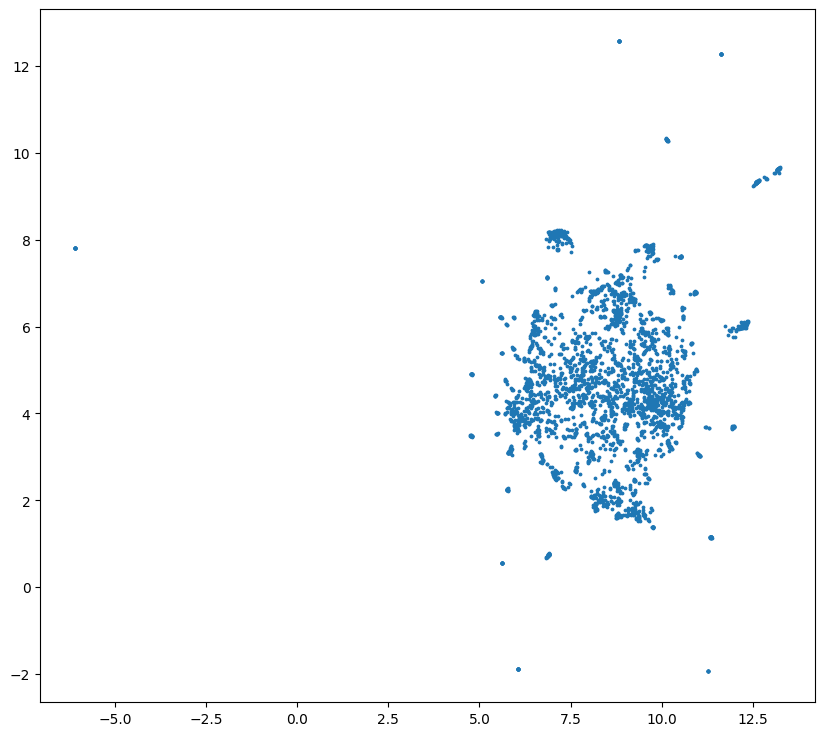

In [25]:
import umap.umap_ as umap
import warnings
warnings.filterwarnings('ignore')

cluster_embedding = umap.UMAP(n_neighbors=30, min_dist=0.0,
                              n_components=2, random_state=42).fit_transform(X)

plt.figure(figsize=(10,9))
plt.scatter(cluster_embedding[:, 0], cluster_embedding[:, 1], s=3, cmap='Spectral');


In [26]:
products = train_df[["StockCode", "Description"]]

# remove duplicates
products.drop_duplicates(inplace=True, subset='StockCode', keep="last")

products_dict = products.groupby('StockCode')['Description'].apply(list).to_dict()


In [27]:
products_dict['84029E']


['RED WOOLLY HOTTIE WHITE HEART.']

In [28]:
def similar_products(v, n = 5):

    # extract most similar products
    ms = model.wv.most_similar([v], topn= n+1)[1:]

    # extract name and similarity score
    new_ms = []
    for j in ms:
        pair = (products_dict[j[0]][0], j[1])
        new_ms.append(pair)

    return new_ms


In [29]:
products_dict['22112']


['CHOCOLATE HOT WATER BOTTLE']

In [30]:
similar_products(model.wv['22112'])


[('HOT WATER BOTTLE I AM SO POORLY', 0.9018763899803162),
 ('HOT WATER BOTTLE TEA AND SYMPATHY', 0.8315613269805908),
 ('SCOTTIE DOG HOT WATER BOTTLE', 0.7974611520767212),
 ('RETROSPOT HEART HOT WATER BOTTLE', 0.7965084910392761),
 ('GREY HEART HOT WATER BOTTLE', 0.779197096824646)]

In [31]:
def aggregate_vectors(products):
    product_vec = []
    for i in products:
        try:
            product_vec.append(model.wv[i])
        except KeyError:
            continue

    return np.mean(product_vec, axis=0)


In [32]:
len(purchases_val[0]), len(purchases_val[1])


(297, 103)

In [33]:
aggregate_vectors(purchases_val[0]).shape, aggregate_vectors(purchases_val[1]).shape


((100,), (100,))

In [34]:
similar_products(aggregate_vectors(purchases_val[11]))


[('CREAM HANGING HEART T-LIGHT HOLDER', 0.7165465950965881),
 ('NATURAL SLATE HEART CHALKBOARD ', 0.7048197388648987),
 ('CREAM SWEETHEART MINI CHEST', 0.702839195728302),
 ('GREY HEART HOT WATER BOTTLE', 0.6923766136169434),
 ('CREAM SWEETHEART WALL CABINET', 0.6913020610809326)]

In [35]:
similar_products(aggregate_vectors(purchases_val[11][-10:]))


[('GREY HEART HOT WATER BOTTLE', 0.730087399482727),
 ('RETROSPOT HEART HOT WATER BOTTLE', 0.7094351053237915),
 ('CHOCOLATE HOT WATER BOTTLE', 0.7021231651306152),
 ('CREAM SWEETHEART WALL CABINET', 0.6941502094268799),
 ('CREAM SWEETHEART MINI CHEST', 0.6860916018486023)]